In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.manifold import TSNE
from scipy.stats import ks_2samp

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

In [2]:
train = pd.read_csv('/dis/DS/hungnt/CICModbus2023/train_70_balanced_600.csv')
test = pd.read_csv('/dis/DS/hungnt/CICModbus2023/test_30_600.csv')

# Histogram Overlap Computations (Class 2 vs Class 8)

In [3]:
CLASS_A = 2   # BRUTE FORCE
CLASS_B = 8   # RECON

df_a = train[train['Label'] == CLASS_A]
df_b = train[train['Label'] == CLASS_B]

features = train.drop(columns=['Label']).select_dtypes(include=[np.number]).columns

def histogram_overlap(a, b, bins=100, robust=True):
    """
    Compute histogram overlap between two 1D distributions.
    Overlap ∈ [0,1], higher = more overlap (worse separability)
    """
    a = pd.to_numeric(a, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    b = pd.to_numeric(b, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values

    if len(a) == 0 or len(b) == 0:
        return np.nan

    # Robust range to avoid extreme outliers
    if robust:
        amin, amax = np.percentile(a, [1, 99])
        bmin, bmax = np.percentile(b, [1, 99])
        min_val, max_val = min(amin, bmin), max(amax, bmax)
    else:
        min_val, max_val = min(a.min(), b.min()), max(a.max(), b.max())

    if not np.isfinite(min_val) or not np.isfinite(max_val) or min_val == max_val:
        return 1.0

    hist_a, bin_edges = np.histogram(a, bins=bins, range=(min_val, max_val), density=True)
    hist_b, _         = np.histogram(b, bins=bins, range=(min_val, max_val), density=True)

    bin_width = bin_edges[1] - bin_edges[0]

    overlap = np.minimum(hist_a, hist_b).sum() * bin_width
    return float(overlap)

overlap_results = {}

for f in features:
    ov = histogram_overlap(df_a[f], df_b[f], bins=100, robust=True)
    overlap_results[f] = ov

overlap_df = (
    pd.DataFrame.from_dict(overlap_results, orient='index', columns=['overlap'])
      .dropna()
      .sort_values('overlap')
)

print("Top 10 features with LOWEST overlap (most discriminative):")
display(overlap_df.head(10))

print("\nTop 10 features with HIGHEST overlap (least discriminative):")
display(overlap_df.tail(10))

Top 10 features with LOWEST overlap (most discriminative):


,overlap
Packet_Length_Variance,0.440907
Packet_Length_Mean,0.445738
Average_Packet_Size,0.445738
Packet_Length_Std,0.445738
Fwd_IAT_Min,0.471859
Flow_IAT_Min,0.598153
ACK_Flag_Count,0.615827
Bwd_IAT_Min,0.624590
Fwd_IAT_Mean,0.639217
Flow_IAT_Mean,0.639222



Top 10 features with HIGHEST overlap (least discriminative):


,overlap
Fwd_Bytes/Bulk_Avg,1.0
SYN_Flag_Count,1.0
Packet_Length_Min,1.0
Fwd_PSH_Flags,1.0
Bwd_Packet_Length_Min,1.0
Fwd_Packet_Length_Min,1.0
Fwd_Packet_Length_Max,1.0
Total_Length_of_Fwd_Packet,1.0
FWD_Init_Win_Bytes,1.0
Packet_Length_Max,1.0


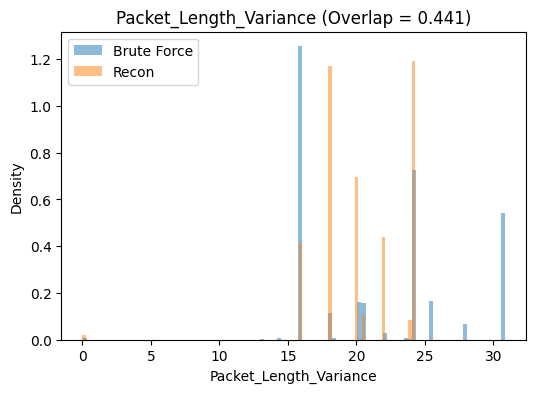

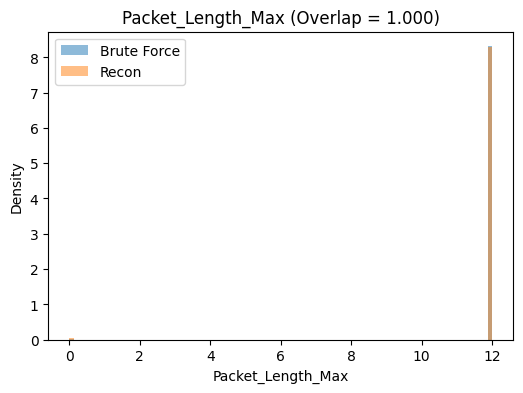

In [4]:
import matplotlib.pyplot as plt

# Chọn feature overlap cao nhất và thấp nhất
low_feat  = overlap_df.index[0]
high_feat = overlap_df.index[-1]

for feat in [low_feat, high_feat]:
    a = df_a[feat].dropna().values
    b = df_b[feat].dropna().values

    plt.figure(figsize=(6,4))
    plt.hist(a, bins=100, density=True, alpha=0.5, label='Brute Force')
    plt.hist(b, bins=100, density=True, alpha=0.5, label='Recon')
    plt.title(f"{feat} (Overlap = {overlap_df.loc[feat, 'overlap']:.3f})")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Kolomogorov Smirnov Test

In [5]:
ks_results = []

for f in features:
    a = pd.to_numeric(df_a[f], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    b = pd.to_numeric(df_b[f], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()

    if len(a) < 10 or len(b) < 10:
        continue

    ks_stat, p_value = ks_2samp(a, b, alternative='two-sided', mode='auto')

    ks_results.append({
        'feature': f,
        'ks_statistic': ks_stat,
        'p_value': p_value
    })

ks_df = (
    pd.DataFrame(ks_results)
      .sort_values('ks_statistic', ascending=False)
      .reset_index(drop=True)
)

print("Top 10 features with LARGEST KS statistic (most different distributions):")
display(ks_df.head(10))

print("\nTop 10 features with SMALLEST KS statistic (most similar distributions):")
display(ks_df.tail(10))

Top 10 features with LARGEST KS statistic (most different distributions):


,feature,ks_statistic,p_value
0,Fwd_IAT_Min,0.529465,2.349589e-142
1,Bwd_IAT_Min,0.386181,4.672142e-74
2,Flow_IAT_Mean,0.364238,9.891706e-66
3,Fwd_IAT_Max,0.364238,9.891706e-66
4,Fwd_IAT_Std,0.364238,9.891706e-66
5,Fwd_IAT_Mean,0.364238,9.891706e-66
6,Fwd_IAT_Total,0.364238,9.891706e-66
7,Flow_IAT_Max,0.364238,9.891706e-66
8,Flow_Duration,0.364238,9.891706e-66
9,Bwd_Packets/s,0.364238,9.891706e-66



Top 10 features with SMALLEST KS statistic (most similar distributions):


,feature,ks_statistic,p_value
70,Active_Std,0.0,1.0
71,Bwd_Bulk_Rate_Avg,0.0,1.0
72,Bwd_Packet/Bulk_Avg,0.0,1.0
73,Bwd_Bytes/Bulk_Avg,0.0,1.0
74,Fwd_Packet/Bulk_Avg,0.0,1.0
75,Fwd_Bytes/Bulk_Avg,0.0,1.0
76,Fwd_Packet_Length_Min,0.0,1.0
77,Packet_Length_Min,0.0,1.0
78,Bwd_Packet_Length_Min,0.0,1.0
79,Protocol,0.0,1.0


# Discriminative Distance

In [6]:
def discriminative_distance(a, b, eps=1e-8):
    """
    Normalized mean distance between two distributions.
    Larger value => better separability.
    """
    mu_a, mu_b = np.mean(a), np.mean(b)
    std_a, std_b = np.std(a), np.std(b)
    return abs(mu_a - mu_b) / (std_a + std_b + eps)

dist_results = []

for f in features:
    a = pd.to_numeric(df_a[f], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    b = pd.to_numeric(df_b[f], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()

    if len(a) < 10 or len(b) < 10:
        continue

    dist = discriminative_distance(a.values, b.values)

    dist_results.append({
        'feature': f,
        'discriminative_distance': dist
    })

dist_df = (
    pd.DataFrame(dist_results)
      .sort_values('discriminative_distance', ascending=False)
      .reset_index(drop=True)
)

print("Top 10 MOST discriminative features (largest distance):")
display(dist_df.head(10))

print("\nTop 10 LEAST discriminative features (smallest distance):")
display(dist_df.tail(10))

Top 10 MOST discriminative features (largest distance):


,feature,discriminative_distance
0,Subflow_Fwd_Bytes,0.678687
1,Subflow_Fwd_Packets,0.678535
2,Subflow_Bwd_Packets,0.678136
3,Fwd_IAT_Max,0.514228
4,Fwd_IAT_Std,0.514184
5,Fwd_IAT_Total,0.514135
6,Fwd_IAT_Mean,0.514030
7,Flow_IAT_Max,0.514026
8,Flow_IAT_Mean,0.513879
9,Flow_Duration,0.513830



Top 10 LEAST discriminative features (smallest distance):


,feature,discriminative_distance
70,Bwd_Packet_Length_Min,0.0
71,Idle_Std,0.0
72,Bwd_Bulk_Rate_Avg,0.0
73,Bwd_Packet/Bulk_Avg,0.0
74,Active_Std,0.0
75,Fwd_Bytes/Bulk_Avg,0.0
76,Fwd_Packet/Bulk_Avg,0.0
77,Fwd_Bulk_Rate_Avg,0.0
78,Bwd_Bytes/Bulk_Avg,0.0
79,Protocol,0.0


=> Kết luận: Sự nhầm lẫn giữa BRUTE FORCE (2) và RECON (8) là do feature-level overlap, đặc biệt ở các feature dựa trên TCP flags và counters

# 2D Visualiazation

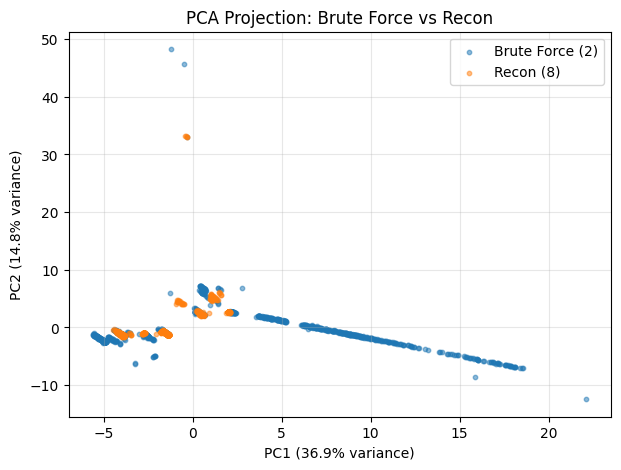

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

CLASS_A = 2   # BRUTE FORCE
CLASS_B = 8   # RECON

df_pca = train[train['Label'].isin([CLASS_A, CLASS_B])].copy()

X = df_pca.drop(columns=['Label'])
y = df_pca['Label']

X = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Tỷ lệ phương sai giải thích
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[y == CLASS_A, 0],
    X_pca[y == CLASS_A, 1],
    alpha=0.5,
    label='Brute Force (2)',
    s=10
)
plt.scatter(
    X_pca[y == CLASS_B, 0],
    X_pca[y == CLASS_B, 1],
    alpha=0.5,
    label='Recon (8)',
    s=10
)

plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.title('PCA Projection: Brute Force vs Recon')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [8]:
# ==============================
# Feature Filtering (SAFE) - FIXED
# ==============================

# 1. Đưa feature từ index thành cột
overlap_df_fix = overlap_df.reset_index().rename(columns={'index': 'feature'})

# 2. Merge 3 bảng
feature_stats = (
    overlap_df_fix
    .merge(ks_df, on='feature', how='inner')
    .merge(dist_df, on='feature', how='inner')
)

print("Merged feature statistics:")
display(feature_stats.head())


Merged feature statistics:


,feature,overlap,ks_statistic,p_value,discriminative_distance
0,Packet_Length_Variance,0.440907,0.286281,2.014037e-40,0.123595
1,Packet_Length_Mean,0.445738,0.286281,2.014037e-40,0.037184
2,Average_Packet_Size,0.445738,0.286281,2.014037e-40,0.037184
3,Packet_Length_Std,0.445738,0.286281,2.014037e-40,0.092311
4,Fwd_IAT_Min,0.471859,0.529465,2.349589e-142,0.489219


In [9]:
# ==============================
# Identify dead features
# ==============================

OVERLAP_TH = 0.90
KS_TH = 0.05
DIST_TH = 0.01

dead_features = feature_stats[
    (feature_stats['overlap'] >= OVERLAP_TH) &
    (feature_stats['ks_statistic'] <= KS_TH) &
    (feature_stats['discriminative_distance'] <= DIST_TH)
]['feature'].tolist()

print(f"Number of dead features: {len(dead_features)}")
print(dead_features)


Number of dead features: 14
['Fwd_Packet_Length_Mean', 'Fwd_Segment_Size_Avg', 'Active_Std', 'Idle_Std', 'Protocol', 'Bwd_Bulk_Rate_Avg', 'Bwd_Packet/Bulk_Avg', 'Bwd_Bytes/Bulk_Avg', 'Fwd_Bulk_Rate_Avg', 'Fwd_Packet/Bulk_Avg', 'Fwd_Bytes/Bulk_Avg', 'Packet_Length_Min', 'Bwd_Packet_Length_Min', 'Fwd_Packet_Length_Min']


In [44]:
# ==============================
# Create filtered datasets
# ==============================

train_filtered = train.drop(columns=dead_features, errors='ignore')
test_filtered  = test.drop(columns=dead_features, errors='ignore')

print("Original feature count :", train.shape[1])
print("Filtered feature count :", train_filtered.shape[1])


Original feature count : 81
Filtered feature count : 67


In [45]:
X_train = train_filtered.drop(['Label'], axis=1)
y_train = train_filtered['Label']
X_test = test_filtered.drop(['Label'], axis=1)
y_test = test_filtered['Label']

In [12]:
import pandas as pd 
import numpy as np
import joblib
import time
import lightgbm as lgb
import sklearn.metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

In [13]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

In [14]:
rf_params = {
    "n_estimators": 100,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy",
    "class_weight": "balanced"
}

print("RandomForestClassifier Starting")
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X=X_train, y=y_train)
rf_start_time = time.time()
rf_prediction = rf_model.predict(X_test)
rf_end_time = time.time()
rf_time = rf_end_time - rf_start_time
print("RandomForestClassifier Finished")

rf_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
rf_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=rf_prediction)
rf_fp = rf_cm[0, 1]
print("RandomForest report:")
print("RandomForest Time:", rf_end_time - rf_start_time)
print("RandomForest Accuracy:", rf_acc)
print("RandomForest Precision:", rf_precision)
print("RandomForest F1:", rf_f1)
print("RandomForest Recall:", rf_recall)
print("RandomForest CM:\n", rf_cm)
rf_tpr, rf_fpr = calculate_macro_tpr_fpr(rf_cm)
print(f'RandomForest Macro-average TPR: {rf_tpr}')
print(f'RandomForest Macro-average FPR: {rf_fpr}')
print(classification_report(y_test, rf_prediction, digits=4))

RandomForestClassifier Starting
RandomForestClassifier Finished
RandomForest report:
RandomForest Time: 0.0805826187133789
RandomForest Accuracy: 0.9579320831221491
RandomForest Precision: 0.9618021498204014
RandomForest F1: 0.9620502325245432
RandomForest Recall: 0.9632155178538887
RandomForest CM:
 [[594   3   1   0   1   0   1   0   0]
 [  0 528   1   0   0   5   0   0  17]
 [  0  16 531   0   0   9   0   0  44]
 [  0   0   0  26   0   0   0   0   0]
 [  0   0   0   0 455   0   1   0   0]
 [  2  15   0   0   0 402   1   0   1]
 [  2   7   0   0   0   3 434   0   1]
 [  2   0   0   0   2   0   0 449   0]
 [  1  12  14   0   0   3   1   0 361]]
RandomForest Macro-average TPR: 0.9632155178538887
RandomForest Macro-average FPR: 0.005320902113510322
              precision    recall  f1-score   support

           0     0.9884    0.9900    0.9892       600
           1     0.9088    0.9583    0.9329       551
           2     0.9707    0.8850    0.9259       600
           3     1.0000  

# SHAP XGBoost vs RF

In [16]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [18]:
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# =========================
# 1) Train RandomForest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    max_leaf_nodes=15000,
    n_jobs=-1,
    random_state=0,
    bootstrap=True,
    criterion="entropy",
    class_weight="balanced"
)
rf.fit(X_train_split, y_train_split)

# =========================
# 2) Train XGBoost
# =========================
xgb_params = {
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor',
    'max_depth': 8,
    'n_estimators': 3000,
    'learning_rate': 0.1,
    'eval_metric': 'mlogloss',
    'objective': 'multi:softprob',
    'num_class': len(np.unique(y_train_split)),
    'booster': 'gbtree',
    'random_state': 42,
    'early_stopping_rounds': 50,
    'n_jobs': -1
}

train_weight = compute_sample_weight("balanced", y_train_split)
val_weight   = compute_sample_weight("balanced", y_val_split)

print("XGBClassifier Starting")
xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train_split, y_train_split,
    sample_weight=train_weight,
    eval_set=[(X_val_split, y_val_split)],
    sample_weight_eval_set=[val_weight],
    verbose=False
)
print("XGBClassifier Finished")

# =========================
# 3) SHAP - RandomForest (MULTI-CLASS)
# =========================
explainer_rf = shap.TreeExplainer(rf)
shap_rf = explainer_rf.shap_values(X_train_split)

shap_rf_abs = np.mean(
    [np.abs(shap_rf[c]).mean(axis=0) for c in range(len(shap_rf))],
    axis=0
)

# =========================
# 4) SHAP - XGBoost (MULTI-CLASS)
# =========================
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_xgb = explainer_xgb.shap_values(X_train_split, check_additivity=False)

shap_xgb_abs = np.mean(
    [np.abs(shap_xgb[c]).mean(axis=0) for c in range(len(shap_xgb))],
    axis=0
)

# =========================
# 5) Normalize + Combine (SAFE)
# =========================
shap_rf_norm = shap_rf_abs / (shap_rf_abs.sum() + 1e-12)
shap_xgb_norm = shap_xgb_abs / (shap_xgb_abs.sum() + 1e-12)

final_score = (shap_rf_norm + shap_xgb_norm) / 2

In [19]:
feature_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'shap_rf': shap_rf_norm,
    'shap_xgb': shap_xgb_norm,
    'final_score': final_score
}).sort_values('final_score', ascending=False)

In [46]:
TOP_K_RF = 50
TOP_K_XGB = 50

features = X_train.columns

top_rf = features[np.argsort(-shap_rf_norm)[:TOP_K_RF]].tolist()
top_xgb = features[np.argsort(-shap_xgb_norm)[:TOP_K_XGB]].tolist()

selected_features = sorted(set(top_rf) | set(top_xgb))

print(f"RF Top-{TOP_K_RF}     : {len(top_rf)}")
print(f"XGB Top-{TOP_K_XGB}  : {len(top_xgb)}")
print(f"Union features       : {len(selected_features)}")

pd.DataFrame({'feature': selected_features}).to_csv(
    "selected_features_topk_union_rf_xgb.csv", index=False
)

RF Top-50     : 50
XGB Top-50  : 50
Union features       : 58


In [47]:
train_shap = train_filtered[selected_features + ['Label']]
test_shap  = test_filtered[selected_features + ['Label']]
print("Original feature count :", train_filtered.shape[1])
print("Filtered feature count :", train_shap.shape[1])

Original feature count : 67
Filtered feature count : 59


In [48]:
X_train = train_shap.drop(['Label'], axis=1)
y_train = train_shap['Label']
X_test = test_shap.drop(['Label'], axis=1)
y_test = test_shap['Label']

In [49]:
rf_params = {
    "n_estimators": 100,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy",
    "class_weight": "balanced"
}

print("RandomForestClassifier Starting")
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X=X_train, y=y_train)
rf_start_time = time.time()
rf_prediction = rf_model.predict(X_test)
rf_end_time = time.time()
rf_time = rf_end_time - rf_start_time
print("RandomForestClassifier Finished")

rf_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
rf_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=rf_prediction, average='macro')
rf_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=rf_prediction)
rf_fp = rf_cm[0, 1]
print("RandomForest report:")
print("RandomForest Time:", rf_end_time - rf_start_time)
print("RandomForest Accuracy:", rf_acc)
print("RandomForest Precision:", rf_precision)
print("RandomForest F1:", rf_f1)
print("RandomForest Recall:", rf_recall)
print("RandomForest CM:\n", rf_cm)
rf_tpr, rf_fpr = calculate_macro_tpr_fpr(rf_cm)
print(f'RandomForest Macro-average TPR: {rf_tpr}')
print(f'RandomForest Macro-average FPR: {rf_fpr}')
print(classification_report(y_test, rf_prediction, digits=4))

RandomForestClassifier Starting
RandomForestClassifier Finished
RandomForest report:
RandomForest Time: 0.09699821472167969
RandomForest Accuracy: 0.9602128737962493
RandomForest Precision: 0.963521174391789
RandomForest F1: 0.9638142641727652
RandomForest Recall: 0.9648793815979863
RandomForest CM:
 [[596   3   0   0   1   0   0   0   0]
 [  0 531   1   0   0   4   0   0  15]
 [  0  14 536   0   0   9   0   0  41]
 [  0   0   0  26   0   0   0   0   0]
 [  0   0   0   0 455   0   1   0   0]
 [  2  12   0   0   0 405   1   0   1]
 [  2   7   0   0   0   6 431   0   1]
 [  2   0   0   0   2   0   0 449   0]
 [  1  11  14   0   0   5   1   0 360]]
RandomForest Macro-average TPR: 0.9648793815979863
RandomForest Macro-average FPR: 0.005029337797066443
              precision    recall  f1-score   support

           0     0.9884    0.9933    0.9909       600
           1     0.9187    0.9637    0.9407       551
           2     0.9728    0.8933    0.9314       600
           3     1.0000  

In [50]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [61]:
xgb_params = {
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor',
    'max_depth': 15,
    'n_estimators': 3000,
    'learning_rate': 0.2,
    'eval_metric': 'mlogloss',
    'objective': 'multi:softprob',
    'num_class': len(np.unique(y_train)),
    'booster': 'gbtree',
    'random_state': 42,
    'early_stopping_rounds': 50,
    'n_jobs': -1
}

train_weight = compute_sample_weight("balanced", y_train_split)
val_weight   = compute_sample_weight("balanced", y_val_split)

print("XGBClassifier Starting")
xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train_split, y_train_split,
    sample_weight=train_weight,
    eval_set=[(X_val_split, y_val_split)],
    sample_weight_eval_set=[val_weight],
    verbose=False
)
print("XGBClassifier Finished")

xgb_start_time = time.time()
xgb_prediction = xgb_model.predict(X_test)
xgb_end_time = time.time()
xgb_time = xgb_end_time - xgb_start_time
xgb_acc = sklearn.metrics.accuracy_score(y_test, xgb_prediction)
xgb_precision = sklearn.metrics.precision_score(y_test, xgb_prediction, average='macro')
xgb_f1 = sklearn.metrics.f1_score(y_test, xgb_prediction, average='macro')
xgb_recall = sklearn.metrics.recall_score(y_test, xgb_prediction, average='macro')
xgb_cm = sklearn.metrics.confusion_matrix(y_test, xgb_prediction)

print("XGBoost report:")
print("XGBoost Time:", xgb_time)
print("XGBoost Accuracy:", xgb_acc)
print("XGBoost Precision:", xgb_precision)
print("XGBoost F1:", xgb_f1)
print("XGBoost Recall:", xgb_recall)
print("XGBoost CM:\n", xgb_cm)
xgb_tpr, xgb_fpr = calculate_macro_tpr_fpr(xgb_cm)
print(f'XGBoost Macro-average TPR: {xgb_tpr}')
print(f'XGBoost Macro-average FPR: {xgb_fpr}')
print(classification_report(y_test, xgb_prediction, digits=4))

XGBClassifier Starting
XGBClassifier Finished
XGBoost report:
XGBoost Time: 0.01400136947631836
XGBoost Accuracy: 0.9432336543335023
XGBoost Precision: 0.9473584369172142
XGBoost F1: 0.9477524875008232
XGBoost Recall: 0.9485634454060483
XGBoost CM:
 [[591   4   0   0   0   0   2   2   1]
 [  1 504   1   0   0  10   1   0  34]
 [  0  12 539   0   0   6   0   0  43]
 [  0   0   0  26   0   0   0   0   0]
 [  0   0   0   0 455   0   1   0   0]
 [  2  17   0   0   0 391   6   0   5]
 [  0  12   0   0   0   5 430   0   0]
 [  1   0   0   0   2   0   0 450   0]
 [  1  15  27   0   0  13   0   0 336]]
XGBoost Macro-average TPR: 0.9485634454060483
XGBoost Macro-average FPR: 0.007170947498419001
              precision    recall  f1-score   support

           0     0.9916    0.9850    0.9883       600
           1     0.8936    0.9147    0.9040       551
           2     0.9506    0.8983    0.9237       600
           3     1.0000    1.0000    1.0000        26
           4     0.9956    0.9978

# EXPORT

In [62]:
train_shap.to_csv(f'/dis/DS/hungnt/CICModbus2023/train_shap_58_600.csv',index=False)
test_shap.to_csv(f'/dis/DS/hungnt/CICModbus2023/test_shap_58_600.csv',index=False)